# Hydrogen Bond Lifetime Survival Analysis

This notebook analyzes hydrogen bond **binding event lifetimes** and plots **survival curves**.

## Survival Analysis Approach

**What we measure:**
- Extract continuous binding events from H-bond time series
- Calculate duration (lifetime) of each event
- Plot survival curves: P(lifetime > t) vs time

**Censoring:**
- **Left-censored**: Bond exists at first analyzed frame (start unknown)
- **Right-censored**: Bond exists at last analyzed frame (end unknown)
- Both types are **discarded** to avoid bias

**Clone aggregation:**
- All binding events are pooled across clones for each system
- This provides better statistics for survival curve estimation

**Data source:** `/data/hbond-atom/` (atom-level H-bond matrices)

In [291]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from typing import Dict, List, Tuple, Optional
from collections import defaultdict
from scipy import stats
from scipy.optimize import curve_fit
from scipy.spatial.distance import jensenshannon
import warnings

# Set plotting style
#sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['font.size'] = 11
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'

## Configuration

In [292]:
# Data directory
DATA_DIR = Path('../data/hbond-atom')

# Analysis parameters
ANALYSIS_START_FRAME = 13000   # Start of production analysis window
ANALYSIS_END_FRAME = 23000     # End of production analysis window
GAP_TOLERANCE = 0              # Frames to bridge gaps (0 = no bridging)
TIME_PER_FRAME_NS = 0.1        # 100 ps = 0.1 ns per frame

# Residue grouping by dataset (residue number ranges)
RESIDUE_GROUPS = {
    '20251112': {
        'eIF5': (844, 849),
        'tRNAi': (1911, 1914),
        'mRNA': (1960, 1962),
        'rRNA': (2425, 2426)
    }
}

# Color scheme for groups (used for title coloring)
GROUP_COLORS = {
    'eIF5': '#8d2788',      # Purple
    'tRNAi': '#23b24b',     # Green
    'mRNA': '#dc7bbb',      # Pink
    'rRNA': '#4994d0',      # Blue
    'Unknown': '#888888'    # Gray
}

# System definitions
SYSTEMS = [
    '20251112_eIF5wt_AUG', '20251112_eIF5wt_ACG', '20251112_eIF5wt_CUG', '20251112_eIF5wt_GUG',
    '20251112_eIF5wt_UUG', '20251112_eIF5wt_AUC',
    '20251112_eIF5_N30K_AUG', '20251112_eIF5_N30Q_AUG', '20251112_eIF5_G29A_G31A_AUG'
]

SYSTEM_LABELS = {
    '20251112_eIF5wt_AUG': 'wt/AUG',
    '20251112_eIF5wt_ACG': 'wt/ACG',
    '20251112_eIF5wt_CUG': 'wt/CUG',
    '20251112_eIF5wt_UUG': 'wt/UUG',
    '20251112_eIF5wt_AUC': 'wt/AUC',
    '20251112_eIF5_N30K_AUG': 'N30K/AUG',
    '20251112_eIF5_N30Q_AUG': 'N30Q/AUG',
    '20251112_eIF5_G29A_G31A_AUG': 'G29A_G31A/AUG'
}

# Color palette for systems
SYSTEM_COLORS = {
    '20251112_eIF5wt_AUG': '#002849',
    '20251112_eIF5wt_ACG': '#6daa48',
    '20251112_eIF5wt_CUG': '#2ba7d8',
    '20251112_eIF5wt_UUG': '#6a3a74',
    '20251112_eIF5wt_AUC': '#faa41a',
    '20251112_eIF5_N30K_AUG': '#067f92',
    '20251112_eIF5_N30Q_AUG': '#3954a4',
    '20251112_eIF5_G29A_G31A_AUG': '#f37039'
}

## Data Loading Functions

In [304]:
def parse_filename(filename: str) -> Optional[Dict[str, str]]:
    """
    Parse filename to extract system information.
    
    Example: 20251112_48S_eIF5wt_AUG_clone0-HB_N30-matrix_atom.dat
    
    Returns:
        Dictionary with date, variant, codon, clone, system keys
    """
    pattern = r'(\d{8})_48S_(eIF5.*?)_(AUG|ACG|CUG|UUG|AUC|GUG)_clone(\d+)-HB_N30-matrix_atom\.dat'
    match = re.match(pattern, filename)
    
    if match:
        return {
            'date': match.group(1),
            'variant': match.group(2),
            'codon': match.group(3),
            'clone': match.group(4),
            'system': f"{match.group(1)}_{match.group(2)}_{match.group(3)}"
        }
    return None

In [294]:
def extract_residue_number(atom_name: str) -> int:
    """
    Extract residue number from atom name.
    
    Examples:
        'A_1911@H2' -> 1911
        'GLY_845@O' -> 845
        'U_1912@O2' -> 1912
    
    Args:
        atom_name: Full atom identifier from column header
    
    Returns:
        Integer residue number, or 0 if not found
    """
    match = re.search(r'_(\d+)@', atom_name)
    return int(match.group(1)) if match else 0

In [295]:
def get_molecule_group(atom_name: str, date: str) -> str:
    """
    Map an atom name to its molecule group based on residue number.
    
    Args:
        atom_name: e.g., 'U_1912@O2', 'GLY_845@O'
        date: Dataset identifier ('20251112')
    
    Returns:
        Group name ('eIF5', 'tRNAi', 'mRNA', 'rRNA', or 'Unknown')
    """
    res_num = extract_residue_number(atom_name)
    if res_num == 0:
        return 'Unknown'
    
    groups = RESIDUE_GROUPS.get(date, {})
    for group_name, (start, end) in groups.items():
        if start <= res_num <= end:
            return group_name
    
    return 'Unknown'

In [296]:
def load_atom_matrix(filepath: Path) -> Tuple[np.ndarray, List[str], Dict[str, str]]:
    """
    Load an atom-level H-bond matrix file.
    
    Returns:
        matrix: 2D array (frames x atoms) of H-bond counts
        atom_names: List of atom column names
        info: Parsed filename information
    """
    info = parse_filename(filepath.name)
    if info is None:
        raise ValueError(f"Could not parse filename: {filepath.name}")
    
    with open(filepath, 'r') as f:
        header = f.readline().strip()
    
    # Split by whitespace (tabs or spaces), skip '#Frame'
    atom_names = header.split()[1:]
    
    data = np.loadtxt(filepath, skiprows=1)
    matrix = data[:, 1:].astype(int)  # Skip frame column
    
    return matrix, atom_names, info

## Lifetime Extraction Functions

In [297]:
def extract_binding_events(
    time_series: np.ndarray,
    gap_tolerance: int = 0
) -> List[Tuple[int, int, bool, bool]]:
    """
    Extract continuous binding events from binary time series.
    
    A binding event is a contiguous stretch where H-bond count >= 1.
    
    Args:
        time_series: 1D array of H-bond counts per frame
        gap_tolerance: Number of frames to bridge gaps (0 = no bridging)
    
    Returns:
        List of (start_frame, end_frame, left_censored, right_censored)
        - start_frame: First frame of binding event (0-indexed)
        - end_frame: Last frame of binding event (inclusive)
        - left_censored: True if event starts at frame 0
        - right_censored: True if event ends at last frame
    """
    events: List[Tuple[int, int, bool, bool]] = []
    n = len(time_series)
    i = 0
    
    while i < n:
        if time_series[i] >= 1:  # Bond exists
            start = i
            # Find end of binding event
            while i < n and time_series[i] >= 1:
                i += 1
            end = i - 1  # Last frame with bond
            
            # Gap tolerance handling (for future extension)
            # For now, gap_tolerance = 0 means no bridging
            
            left_censored = (start == 0)
            right_censored = (end == n - 1)
            events.append((start, end, left_censored, right_censored))
        else:
            i += 1
    
    return events

In [298]:
def filter_complete_events(
    events: List[Tuple[int, int, bool, bool]]
) -> List[Tuple[int, int]]:
    """
    Remove censored events, keeping only complete observations.
    
    Args:
        events: List from extract_binding_events()
    
    Returns:
        List of (start_frame, end_frame) for complete events only
    """
    complete: List[Tuple[int, int]] = []
    for start, end, left_cens, right_cens in events:
        if not left_cens and not right_cens:
            complete.append((start, end))
    return complete

In [299]:
def calculate_lifetimes(
    complete_events: List[Tuple[int, int]]
) -> List[int]:
    """
    Convert complete binding events to lifetimes (in frames).
    
    Lifetime = end_frame - start_frame + 1 (inclusive count)
    
    Args:
        complete_events: List of (start_frame, end_frame)
    
    Returns:
        List of lifetimes in frames
    """
    return [end - start + 1 for start, end in complete_events]

## Survival Function Calculation

In [300]:
def calculate_survival_function(
    lifetimes: List[int],
    time_per_frame_ns: float = TIME_PER_FRAME_NS
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Calculate empirical survival function: S(t) = P(lifetime > t)
    
    Uses the complement of the empirical CDF (ECDF).
    S(t) = 1 - F(t) where F(t) is the proportion of events with lifetime <= t.
    
    Args:
        lifetimes: List of lifetimes in frames
        time_per_frame_ns: Conversion factor (ns per frame)
    
    Returns:
        time_points_ns: Array of time values in nanoseconds
        survival_probability: Array of S(t) values (monotonically decreasing)
    """
    if len(lifetimes) == 0:
        return np.array([0.0]), np.array([1.0])
    
    # Sort lifetimes
    sorted_lifetimes = np.sort(lifetimes)
    n = len(sorted_lifetimes)
    
    # Calculate survival at each unique lifetime
    unique_lifetimes = np.unique(sorted_lifetimes)
    
    # Start with S(0) = 1.0 (all events survive at t=0)
    time_points = [0]
    survival = [1.0]
    
    for t in unique_lifetimes:
        # S(t) = proportion with lifetime > t
        s_t = np.sum(sorted_lifetimes > t) / n
        time_points.append(t)
        survival.append(s_t)
    
    # Convert to nanoseconds
    time_points_ns = np.array(time_points) * time_per_frame_ns
    survival_probability = np.array(survival)
    
    return time_points_ns, survival_probability

In [301]:
def find_median_lifetime(
    time_points: np.ndarray,
    survival: np.ndarray
) -> Optional[float]:
    """
    Find median lifetime (time at 50% survival) by interpolation.
    
    Args:
        time_points: Array of time values (ns)
        survival: Array of survival probabilities
    
    Returns:
        Median lifetime in ns, or None if survival never drops below 0.5
    """
    if len(time_points) < 2:
        return None
    
    # Find where survival crosses 0.5
    for i in range(len(survival) - 1):
        if survival[i] >= 0.5 and survival[i + 1] < 0.5:
            # Linear interpolation
            t1, t2 = time_points[i], time_points[i + 1]
            s1, s2 = survival[i], survival[i + 1]
            median = t1 + (0.5 - s1) * (t2 - t1) / (s2 - s1)
            return median
    
    # Check if survival starts below 0.5
    if survival[0] < 0.5:
        return 0.0
    
    # Survival never drops below 0.5
    return None

In [302]:
def biexponential(
    t: np.ndarray,
    a1: float,
    tau1: float,
    a2: float,
    tau2: float
) -> np.ndarray:
    """
    Biexponential decay function for survival curve fitting.
    
    S(t) = a1 * exp(-t/tau1) + a2 * exp(-t/tau2)
    
    Args:
        t: Time values
        a1: Amplitude of fast component
        tau1: Time constant of fast component (ns)
        a2: Amplitude of slow component
        tau2: Time constant of slow component (ns)
    
    Returns:
        Survival probability at each time point
    """
    return a1 * np.exp(-t / tau1) + a2 * np.exp(-t / tau2)


def fit_biexponential(
    time_pts: np.ndarray,
    survival: np.ndarray,
    max_time: Optional[float] = None
) -> Optional[Dict]:
    """
    Fit biexponential decay to survival curve data.
    
    Args:
        time_pts: Time values in ns
        survival: Survival probabilities
        max_time: Maximum time to include in fit (ns)
    
    Returns:
        Dictionary with fit parameters, or None if fit fails:
        - 'a1', 'tau1': Fast component amplitude and time constant
        - 'a2', 'tau2': Slow component amplitude and time constant
        - 'params': Full parameter array [a1, tau1, a2, tau2]
        - 'pcov': Covariance matrix
        - 'r_squared': Goodness of fit
    """
    # Filter data
    if max_time is not None:
        mask = time_pts <= max_time
        time_pts = time_pts[mask]
        survival = survival[mask]
    
    # Need at least 5 points for 4 parameters
    if len(time_pts) < 5:
        return None
    
    # Skip t=0 point (always S=1) for better fitting
    if time_pts[0] == 0:
        time_pts = time_pts[1:]
        survival = survival[1:]
    
    if len(time_pts) < 5:
        return None
    
    try:
        # Initial guesses: split amplitude 50/50, guess time constants
        t_median = np.median(time_pts)
        p0 = [0.5, t_median * 0.3, 0.5, t_median * 2.0]
        
        # Bounds: amplitudes [0, 1], time constants [0.01, large]
        bounds = (
            [0.0, 0.01, 0.0, 0.01],      # Lower bounds
            [1.0, 1000.0, 1.0, 1000.0]    # Upper bounds
        )
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            popt, pcov = curve_fit(
                biexponential, time_pts, survival,
                p0=p0, bounds=bounds, maxfev=5000
            )
        
        # Calculate R-squared
        y_pred = biexponential(time_pts, *popt)
        ss_res = np.sum((survival - y_pred) ** 2)
        ss_tot = np.sum((survival - np.mean(survival)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        # Ensure tau1 < tau2 (tau1 is fast, tau2 is slow)
        if popt[1] > popt[3]:
            popt = [popt[2], popt[3], popt[0], popt[1]]
        
        return {
            'a1': popt[0],
            'tau1': popt[1],
            'a2': popt[2],
            'tau2': popt[3],
            'params': popt,
            'pcov': pcov,
            'r_squared': r_squared
        }
    except (RuntimeError, ValueError):
        return None

## Load Data and Process Lifetimes

In [305]:
# Load all atom matrix files and organize by system
all_files = sorted(DATA_DIR.glob('*-matrix_atom.dat'))
print(f"Found {len(all_files)} atom matrix files")

# Organize by system
systems_files: Dict[str, List[Path]] = {}
for filepath in all_files:
    info = parse_filename(filepath.name)
    if info is None:
        continue
    
    system_key = info['system']
    if system_key not in systems_files:
        systems_files[system_key] = []
    systems_files[system_key].append(filepath)

print(f"Organized into {len(systems_files)} unique systems")
for system_key in sorted(systems_files.keys()):
    print(f"  {system_key}: {len(systems_files[system_key])} clones")

Found 72 atom matrix files
Organized into 9 unique systems
  20251112_eIF5_G29A_G31A_AUG: 8 clones
  20251112_eIF5_N30K_AUG: 8 clones
  20251112_eIF5_N30Q_AUG: 8 clones
  20251112_eIF5wt_ACG: 8 clones
  20251112_eIF5wt_AUC: 8 clones
  20251112_eIF5wt_AUG: 8 clones
  20251112_eIF5wt_CUG: 8 clones
  20251112_eIF5wt_GUG: 8 clones
  20251112_eIF5wt_UUG: 8 clones


In [306]:
def process_all_lifetimes(
    systems_files: Dict[str, List[Path]],
    start_frame: int = ANALYSIS_START_FRAME,
    end_frame: int = ANALYSIS_END_FRAME,
    gap_tolerance: int = GAP_TOLERANCE
) -> Tuple[Dict[str, Dict[str, List[int]]], set]:
    """
    Process all systems and extract lifetimes for each atom.
    
    Pools events across all clones for each system.
    
    Args:
        systems_files: Dict mapping system_key -> list of file paths
        start_frame: Start of analysis window
        end_frame: End of analysis window
        gap_tolerance: Frames to bridge gaps
    
    Returns:
        all_lifetimes: Dict[system][atom] -> list of lifetimes (frames)
        all_atoms: Set of all unique atom names
    """
    all_lifetimes: Dict[str, Dict[str, List[int]]] = {}
    all_atoms: set = set()
    
    for system_key, file_paths in sorted(systems_files.items()):
        print(f"Processing {system_key}...")
        system_lifetimes: Dict[str, List[int]] = defaultdict(list)
        
        for filepath in file_paths:
            matrix, atom_names, info = load_atom_matrix(filepath)
            all_atoms.update(atom_names)
            
            # Window the matrix
            matrix_windowed = matrix[start_frame:end_frame, :]
            
            for i, atom_name in enumerate(atom_names):
                time_series = matrix_windowed[:, i]
                events = extract_binding_events(time_series, gap_tolerance)
                complete = filter_complete_events(events)
                lifetimes = calculate_lifetimes(complete)
                system_lifetimes[atom_name].extend(lifetimes)
        
        all_lifetimes[system_key] = dict(system_lifetimes)
    
    return all_lifetimes, all_atoms


print(f"Analysis parameters:")
print(f"  Frame range: {ANALYSIS_START_FRAME} - {ANALYSIS_END_FRAME}")
print(f"  Gap tolerance: {GAP_TOLERANCE} frames")
print(f"  Time per frame: {TIME_PER_FRAME_NS} ns\n")

all_lifetimes, all_atoms = process_all_lifetimes(systems_files)
print(f"\nTotal unique atoms: {len(all_atoms)}")

Analysis parameters:
  Frame range: 13000 - 23000
  Gap tolerance: 0 frames
  Time per frame: 0.1 ns

Processing 20251112_eIF5_G29A_G31A_AUG...
Processing 20251112_eIF5_N30K_AUG...
Processing 20251112_eIF5_N30Q_AUG...
Processing 20251112_eIF5wt_ACG...
Processing 20251112_eIF5wt_AUC...
Processing 20251112_eIF5wt_AUG...
Processing 20251112_eIF5wt_CUG...
Processing 20251112_eIF5wt_GUG...
Processing 20251112_eIF5wt_UUG...

Total unique atoms: 225


In [307]:
def calculate_all_survival_curves(
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    time_per_frame_ns: float = TIME_PER_FRAME_NS
) -> Dict[str, Dict[str, Tuple[np.ndarray, np.ndarray]]]:
    """
    Calculate survival curves for all system-atom combinations.
    
    Args:
        all_lifetimes: Dict[system][atom] -> list of lifetimes
        time_per_frame_ns: Conversion factor
    
    Returns:
        Dict[system][atom] -> (time_points_ns, survival_probability)
    """
    survival_curves: Dict[str, Dict[str, Tuple[np.ndarray, np.ndarray]]] = {}
    
    for system_key, atom_lifetimes in all_lifetimes.items():
        survival_curves[system_key] = {}
        for atom_name, lifetimes in atom_lifetimes.items():
            time_pts, surv_prob = calculate_survival_function(
                lifetimes, time_per_frame_ns
            )
            survival_curves[system_key][atom_name] = (time_pts, surv_prob)
    
    return survival_curves


all_survival_curves = calculate_all_survival_curves(all_lifetimes)
print("Calculated survival curves for all system-atom combinations.")

Calculated survival curves for all system-atom combinations.


## Plotting Functions

In [308]:
def plot_survival_curves(
    survival_curves: Dict[str, Dict[str, Tuple[np.ndarray, np.ndarray]]],
    all_lifetimes: Dict[str, Dict[str, List[int]]],
    selected_atom: str,
    selected_systems: List[str],
    show_median: bool = True,
    show_fit: bool = True,
    x_max: Optional[float] = None,
    figsize: Tuple[float, float] = (10, 7)
) -> plt.Figure:
    """
    Plot survival curves for selected atom across systems.
    
    Args:
        survival_curves: Dict[system][atom] -> (time_points, survival)
        all_lifetimes: Dict[system][atom] -> list of lifetimes (for n_events)
        selected_atom: Atom to plot
        selected_systems: Systems to include
        show_median: Whether to show median lifetime in legend
        show_fit: Whether to show biexponential fit lines
        x_max: Maximum x-axis value (ns), None for auto
        figsize: Figure size as (width, height)
    
    Returns:
        matplotlib Figure
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    median_lifetimes: Dict[str, Optional[float]] = {}
    fit_results: Dict[str, Optional[Dict]] = {}
    
    for system_key in selected_systems:
        if system_key not in survival_curves:
            continue
        if selected_atom not in survival_curves[system_key]:
            continue
        
        time_pts, surv_prob = survival_curves[system_key][selected_atom]
        n_events = len(all_lifetimes.get(system_key, {}).get(selected_atom, []))
        color = SYSTEM_COLORS.get(system_key, 'gray')
        
        # Calculate median
        median = find_median_lifetime(time_pts, surv_prob)
        median_lifetimes[system_key] = median
        
        # Build label with median if requested
        label = SYSTEM_LABELS.get(system_key, system_key)
        if show_median and median is not None:
            label += f" (n={n_events}, t½={median:.2f} ns)"
        else:
            label += f" (n={n_events})"
        
        # Plot scatter points (filter out t=0 for log scale)
        mask = time_pts > 0
        ax.scatter(time_pts[mask], surv_prob[mask], color=color, s=20, label=label, edgecolor=color, facecolors='none')
        
        # Fit and plot biexponential
        if show_fit:
            fit_result = fit_biexponential(time_pts, surv_prob, max_time=x_max)
            fit_results[system_key] = fit_result
            
            if fit_result is not None:
                # Generate smooth curve for fit line
                t_fit = np.linspace(0.01, time_pts.max(), 300)
                if x_max is not None:
                    t_fit = np.linspace(0.01, min(time_pts.max(), x_max), 300)
                y_fit = biexponential(t_fit, *fit_result['params'])
                ax.plot(t_fit, y_fit, color=color, linewidth=1)
    
    # Add 50% line
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5, linewidth=1)
    
    # Get molecule group for title coloring
    group = get_molecule_group(selected_atom, '20251112')
    title_color = GROUP_COLORS.get(group, 'black')
    
    ax.set_xlabel('Time (ns)', fontsize=12)
    ax.set_ylabel('Survival Probability S(t)', fontsize=12)
    ax.set_title(f'H-bond Lifetime Survival: {selected_atom}',
                fontsize=14, fontweight='bold', color=title_color)
    
    # Set log scale for x-axis
    ax.set_xscale('log')
    ax.set_xlim(0.07, 10)
    
    # Y-axis: 0 to 1
    ax.set_ylim(0, 1.0)
    ax.set_yticks(np.arange(0,1.1,0.1))
    
    # Remove grid lines
    ax.grid(False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Tick marks on outside - enable minor ticks for log scale
    ax.tick_params(axis='both', which='major', direction='out', length=6, width=1)
    ax.tick_params(axis='both', which='minor', direction='out', length=3, width=0.5)
    
    ax.legend(loc='upper right', fontsize=9)
    
    plt.tight_layout()
    return fig

## Example 1: Compare Start Codons (wt eIF5)

Compare H-bond lifetime distributions for wild-type eIF5 across different start codons.

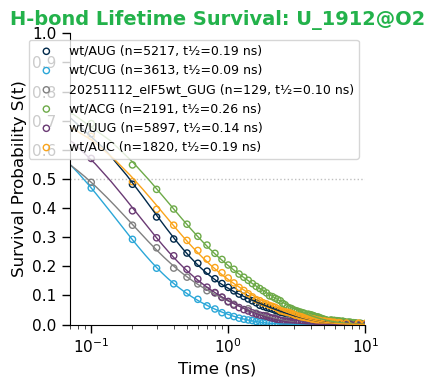

In [309]:
# ============================================================
# USER SELECTION: Modify to change the comparison
# ============================================================

# Select atom to analyze
SELECTED_ATOM = 'U_1912@O2'

# Select systems (different codons, wt eIF5)
CODON_COMPARISON_SYSTEMS = [
    '20251112_eIF5wt_AUG',
    '20251112_eIF5wt_CUG',
    '20251112_eIF5wt_GUG',
    '20251112_eIF5wt_ACG',
    '20251112_eIF5wt_UUG',
    '20251112_eIF5wt_AUC'
]

# ============================================================

fig = plot_survival_curves(
    all_survival_curves,
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=CODON_COMPARISON_SYSTEMS,
    show_median=True,
    show_fit=True,
    figsize=(4,4)
)
#plt.show()
plt.savefig("hbond_survival_startsites.svg")

## Example 2: Compare Mutants vs Wild-Type (AUG)

Compare H-bond lifetime distributions for eIF5 mutants with AUG codon.

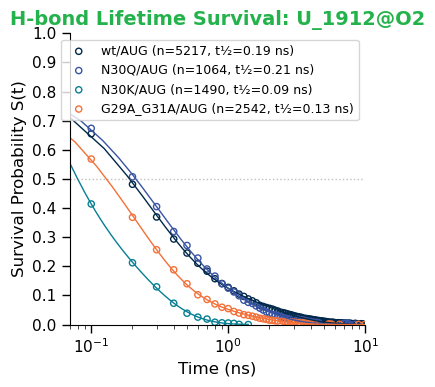

In [290]:
# ============================================================
# Compare eIF5 mutants with AUG codon
# ============================================================

SELECTED_ATOM = 'U_1912@O2'

MUTANT_COMPARISON_SYSTEMS = [
    '20251112_eIF5wt_AUG',
    '20251112_eIF5_N30Q_AUG',
    '20251112_eIF5_N30K_AUG',
    '20251112_eIF5_G29A_G31A_AUG'
]

# ============================================================

fig = plot_survival_curves(
    all_survival_curves,
    all_lifetimes,
    selected_atom=SELECTED_ATOM,
    selected_systems=MUTANT_COMPARISON_SYSTEMS,
    show_median=True,
    show_fit=True, figsize=(4,4)
)
plt.savefig("hbond_survival_eif5mutants.svg")